# Welcome!

This is intended to be a quick how-to guide centered on the topic of producing 3D Gaussian splats from YouTube video URLs. The specific video we focus on is of Bamburgh Castle created by @Xploreheritage ([xploreheritage.com](xploreheritage.com)); thanks for your great video! After extracting 8 FPS from the video, we produce an image dataset of ~1,100 images and a 3D Gaussian splat therefrom in less than two hours ([link to viewer](https://nickmccarty.me/bamburgh-castle-splat)).

In [ ]:
#   (\ /)     How to Produce a 3D Gaussian Splat from a YouTube Video URL
#   ( - -)    written by nick@upskilled.consulting
#   c(")(")   with ♡ for the GS community

from IPython.display import IFrame

# Define the URL of the webpage
url = "https://nickmccarty.me/bamburgh-castle-splat"

# Render the iframe with the specified width and height
IFrame(src=url, width="100%", height="600")

# Shout out to Kevin Kwok for developing the viewer!

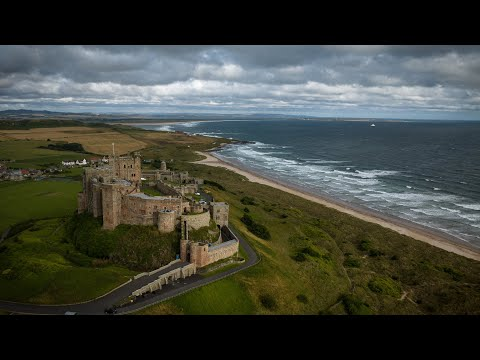

In [ ]:
from IPython.display import YouTubeVideo

# Video ID from your YouTube URL
video_id = "nefKdNDJR9M"

# Embed the video
YouTubeVideo(video_id)

In [ ]:
import time

workflow_steps = []
step_duration = []

workflow_steps.append('Video processing dependency installation')
start_time = time.time()  # Start timing

In [ ]:
# # Install yt-dlp for downloading the YouTube video
!pip install yt-dlp

# Install ffmpeg for extracting frames from the video
!apt-get install -y ffmpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.1/172.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.6 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


In [ ]:
end_time = time.time()  # End timing
elapsed_time = end_time - start_time  # Calculate elapsed time
step_duration.append(elapsed_time)

print(f'YouTube video ingestion and processing dependencies installed.')
print(f'Elapsed time: {elapsed_time:.2f} seconds')

YouTube video ingestion and processing dependencies installed.
Elapsed time: 11.50 seconds


In [ ]:
workflow_steps.append('Data ingestion/processing')
start_time = time.time()  # Start timing

In [ ]:
from yt_dlp import YoutubeDL

url = "https://youtu.be/nefKdNDJR9M?si=4PDguQYUWTdTtZtG"

ydl_opts = {
    'format': 'best',
    'outtmpl': 'downloaded_video.%(ext)s',  # Save the video with this name
}

with YoutubeDL(ydl_opts) as ydl:
    ydl.download([url])

[youtube] Extracting URL: https://youtu.be/nefKdNDJR9M?si=4PDguQYUWTdTtZtG
[youtube] nefKdNDJR9M: Downloading webpage
[youtube] nefKdNDJR9M: Downloading ios player API JSON
[youtube] nefKdNDJR9M: Downloading mweb player API JSON
[youtube] nefKdNDJR9M: Downloading player b46bb280
[youtube] nefKdNDJR9M: Downloading m3u8 information
[info] nefKdNDJR9M: Downloading 1 format(s): 18
[download] Destination: downloaded_video.mp4
[download] 100% of    5.94MiB in 00:00:00 at 8.77MiB/s   


In [ ]:
!mkdir images
!ffmpeg -i downloaded_video.mp4 -qscale:v 1 -qmin 1 -vf "fps=8" images/%04d.jpg

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
import os

# Specify the folder path
folder_path = "images"

# Count the number of files
file_count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])

print(f"Number of files in '{folder_path}' folder: {file_count}")

Number of files in 'images' folder: 1179


In [ ]:
end_time = time.time()  # End timing
elapsed_time = end_time - start_time  # Calculate elapsed time
step_duration.append(elapsed_time)

print(f'Video processing complete; image dataset created.')
print(f'Elapsed time: {elapsed_time:.2f} seconds')

Video processing complete; image dataset created.
Elapsed time: 17.03 seconds


In [ ]:
workflow_steps.append('Reconstruction dependency installation')
start_time = time.time()  # Start timing

In [ ]:
# I used Git LFS to push the pre-built libraries to my GitHub repo for quicker installation;
# see my COLMAP Reconstruction tutorial for a complete walkthrough of how to install COLMAP/GLOMAP from scratch:
# https://colab.research.google.com/drive/1c0RrDO3hgD8Zv0dWMTQQ__bwy2qdGhwM?usp=sharing#offline=true&sandboxMode=true

!wget https://github.com/nickmccarty/3dgs-workshop/raw/refs/heads/master/colmap.zip
!wget https://github.com/nickmccarty/3dgs-workshop/raw/refs/heads/master/glomap.zip

--2024-11-30 15:27:37--  https://github.com/nickmccarty/3dgs-workshop/raw/refs/heads/master/colmap.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/nickmccarty/3dgs-workshop/refs/heads/master/colmap.zip [following]
--2024-11-30 15:27:37--  https://media.githubusercontent.com/media/nickmccarty/3dgs-workshop/refs/heads/master/colmap.zip
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42142494 (40M) [application/zip]
Saving to: ‘colmap.zip’

colmap.zip          100%[===================>]  40.19M   258MB/s    in 0.2s    

2024-11-30 15:27:41 (258 MB/s) - ‘colmap.zip’ saved [42

In [ ]:
!unzip colmap.zip
!unzip glomap.zip

Archive:  colmap.zip
   creating: colmap/benchmark/
  inflating: colmap/benchmark/cost_functions.cc  
  inflating: colmap/benchmark/CMakeLists.txt  
  inflating: colmap/benchmark/README.md  
   creating: colmap/build/
  inflating: colmap/build/colmap-config.cmake  
  inflating: colmap/build/CMakeCache.txt  
  inflating: colmap/build/build.ninja  
  inflating: colmap/build/.ninja_log  
  inflating: colmap/build/cmake_install.cmake  
  inflating: colmap/build/install_manifest.txt  
   creating: colmap/build/CMakeFiles/
  inflating: colmap/build/CMakeFiles/clean_additional.cmake  
   creating: colmap/build/CMakeFiles/3.30.5/
  inflating: colmap/build/CMakeFiles/3.30.5/CMakeCCompiler.cmake  
   creating: colmap/build/CMakeFiles/3.30.5/CompilerIdCXX/
   creating: colmap/build/CMakeFiles/3.30.5/CompilerIdCXX/tmp/
  inflating: colmap/build/CMakeFiles/3.30.5/CompilerIdCXX/CMakeCXXCompilerId.cpp  
  inflating: colmap/build/CMakeFiles/3.30.5/CompilerIdCXX/a.out  
  inflating: colmap/build/CMakeF

In [ ]:
import os
os.environ['PATH'] += ':/content/colmap/build/src/colmap/exe'
os.environ['PATH'] += ':/content/glomap-1.0.0/build/glomap'

In [ ]:
!sudo apt-get install \
    git \
    cmake \
    ninja-build \
    build-essential \
    libboost-program-options-dev \
    libboost-filesystem-dev \
    libboost-graph-dev \
    libboost-system-dev \
    libeigen3-dev \
    libflann-dev \
    libfreeimage-dev \
    libmetis-dev \
    libgoogle-glog-dev \
    libgtest-dev \
    libsqlite3-dev \
    libglew-dev \
    qtbase5-dev \
    libqt5opengl5-dev \
    libcgal-dev \
    libceres-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
libboost-filesystem-dev is already the newest version (1.74.0.3ubuntu7).
libboost-filesystem-dev set to manually installed.
libboost-program-options-dev is already the newest version (1.74.0.3ubuntu7).
libboost-program-options-dev set to manually installed.
libboost-system-dev is already the newest version (1.74.0.3ubuntu7).
libboost-system-dev set to manually installed.
libboost-graph-dev is already the newest version (1.74.0.3ubuntu7).
libboost-graph-dev set to manually installed.
cmake is already the newest version (3.22.1-1ubuntu1.22.04.2).
git is already the newest version (1:2.34.1-1ubuntu1.11).
libsqlite3-dev is already the newest version (3.37.2-2ubuntu0.3).
libsqlite3-dev set to manually installed.
The following additional packages will be installed:
  googletest libamd2 libbtf1 libcamd2 libccolamd2 libceres2 libcholmod3


In [ ]:
!sudo apt-get install -y \
    nvidia-cuda-toolkit \
    nvidia-cuda-toolkit-gcc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-dejavu-core fonts-dejavu-extra libaccinj64-11.5 libatk-wrapper-java
  libatk-wrapper-java-jni libbabeltrace1 libcub-dev libcublas11 libcublaslt11
  libcudart11.0 libcufft10 libcufftw10 libcuinj64-11.5 libcupti-dev
  libcupti-doc libcupti11.5 libcurand10 libcusolver11 libcusolvermg11
  libcusparse11 libdebuginfod-common libdebuginfod1 libfontenc1 libgail-common
  libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libipt2 libnppc11
  libnppial11 libnppicc11 libnppidei11 libnppif11 libnppig11 libnppim11
  libnppist11 libnppisu11 libnppitc11 libnpps11 libnvblas11
  libnvidia-compute-495 libnvidia-compute-510 libnvidia-compute-535
  libnvidia-ml-dev libnvjpeg11 libnvrtc-builtins11.5 libnvrtc11.2
  libnvtoolsext1 libnvvm4 librsvg2-common libsource-highlight-common
  libsource-highlight4v5 libthrust-dev libvdpau-dev libxkbfile1 libxtst

In [ ]:
end_time = time.time()  # End timing
elapsed_time = end_time - start_time  # Calculate elapsed time
step_duration.append(elapsed_time)

print(f'Reconstruction dependencies installed.')
print(f'Elapsed time: {elapsed_time:.2f} seconds')

Reconstruction dependencies installed.
Elapsed time: 174.26 seconds


In [ ]:
workflow_steps.append('Sparse reconstruction')
start_time = time.time()  # Start timing

In [ ]:
project_name="bamburgh_castle"

!mkdir $project_name
!mv images $project_name/images

In [ ]:
!colmap feature_extractor \
   --database_path $project_name/database.db \
   --image_path $project_name/images \
   --ImageReader.camera_model PINHOLE

Streaming output truncated to the last 5000 lines.
I1130 15:31:37.867147  3465 feature_extraction.cc:280]   Features:        2440
I1130 15:31:37.878103  3465 feature_extraction.cc:258] Processed file [347/1179]
I1130 15:31:37.878144  3465 feature_extraction.cc:261]   Name:            0347.jpg
I1130 15:31:37.878152  3465 feature_extraction.cc:270]   Dimensions:      640 x 272
I1130 15:31:37.878160  3465 feature_extraction.cc:273]   Camera:          #1 - PINHOLE
I1130 15:31:37.878168  3465 feature_extraction.cc:276]   Focal Length:    768.00px
I1130 15:31:37.878180  3465 feature_extraction.cc:280]   Features:        2508
I1130 15:31:37.889077  3465 feature_extraction.cc:258] Processed file [348/1179]
I1130 15:31:37.889117  3465 feature_extraction.cc:261]   Name:            0348.jpg
I1130 15:31:37.889125  3465 feature_extraction.cc:270]   Dimensions:      640 x 272
I1130 15:31:37.889133  3465 feature_extraction.cc:273]   Camera:          #1 - PINHOLE
I1130 15:31:37.889142  3465 feature_ex

In [ ]:
!colmap exhaustive_matcher \
   --database_path $project_name/database.db

I1129 21:09:09.111449  3485 misc.cc:44] 
Feature matching
I1129 21:09:09.115919  3486 sift.cc:1426] Creating SIFT GPU feature matcher
I1129 21:09:09.242336  3485 pairing.cc:168] Generating exhaustive image pairs...
I1129 21:09:09.242388  3485 pairing.cc:201] Matching block [1/24, 1/24]
I1129 21:09:12.257144  3485 feature_matching.cc:46] in 3.015s
I1129 21:09:12.273075  3485 pairing.cc:201] Matching block [1/24, 2/24]
I1129 21:09:13.555641  3485 feature_matching.cc:46] in 1.283s
I1129 21:09:13.557338  3485 pairing.cc:201] Matching block [1/24, 3/24]
I1129 21:09:14.042726  3485 feature_matching.cc:46] in 0.485s
I1129 21:09:14.043874  3485 pairing.cc:201] Matching block [1/24, 4/24]
I1129 21:09:14.562731  3485 feature_matching.cc:46] in 0.519s
I1129 21:09:14.566404  3485 pairing.cc:201] Matching block [1/24, 5/24]
I1129 21:09:15.097347  3485 feature_matching.cc:46] in 0.531s
I1129 21:09:15.098618  3485 pairing.cc:201] Matching block [1/24, 6/24]
I1129 21:09:15.773142  3485 feature_matchin

In [ ]:
# !mkdir $project_name/sparse
# !colmap mapper \
#     --database_path $project_name/database.db \
#     --image_path $project_name/images \
#     --output_path $project_name/sparse \
#     --Mapper.ba_global_function_tolerance=0.000001

In [ ]:
!glomap mapper \
    --database_path $project_name/database.db \
    --image_path $project_name/images \
    --output_path $project_name/sparse

 Loading Images 1179 / 1179
 Loading Image Pair 133000 / 133000
I1129 21:16:51.409374  5437 colmap_converter.cc:303] Pairs read done. 6058 / 133000 are invalid
I1129 21:16:51.429360  5437 global_mapper.cc:80] Loaded database
-------------------------------------
Running preprocessing ...
-------------------------------------
I1129 21:16:51.491139  5437 view_graph_manipulation.cc:246] Decompose relative pose for 0 pairs
I1129 21:16:51.491725  5437 view_graph_manipulation.cc:295] Decompose relative pose done. 0 pairs are pure rotation
I1129 21:16:51.491742  5437 timer.cc:87] Elapsed time: 0.06229 [seconds]
-------------------------------------
Running view graph calibration ...
-------------------------------------
I1129 21:16:51.491767  5437 view_graph_calibration.cc:16] Start ViewGraphCalibrator
I1129 21:16:51.849148  5437 view_graph_calibration.cc:155] 0 cameras are rejected in view graph calibration
I1129 21:16:51.889294  5437 view_graph_calibration.cc:189] invalid / total number of 

In [ ]:
%mkdir $project_name/dense
!colmap image_undistorter \
    --image_path $project_name/images \
    --input_path $project_name/sparse/0 \
    --output_path $project_name/dense \
    --output_type COLMAP

I1129 22:19:11.366568 21330 misc.cc:44] 
Reading reconstruction
I1129 22:19:11.536365 21330 image.cc:347] => Reconstruction with 585 images and 14452 points
I1129 22:19:11.536446 21330 misc.cc:44] 
Image undistortion
I1129 22:19:11.538000 21332 undistortion.cc:257] Undistorted image found; copying to location: bamburgh_castle_reconstruction/dense/images/0388.jpg
I1129 22:19:11.538236 21332 undistortion.cc:257] Undistorted image found; copying to location: bamburgh_castle_reconstruction/dense/images/0389.jpg
I1129 22:19:11.538327 21330 undistortion.cc:215] Undistorting image [1/585]
I1129 22:19:11.538403 21333 undistortion.cc:257] Undistorted image found; copying to location: bamburgh_castle_reconstruction/dense/images/0387.jpg
I1129 22:19:11.538422 21332 undistortion.cc:257] Undistorted image found; copying to location: bamburgh_castle_reconstruction/dense/images/0390.jpg
I1129 22:19:11.538579 21333 undistortion.cc:257] Undistorted image found; copying to location: bamburgh_castle_reco

In [ ]:
!colmap model_converter \
  --input_path $project_name/sparse/0 \
  --output_path $project_name/sparse/0 \
  --output_type TXT

In [ ]:
end_time = time.time()  # End timing
elapsed_time = end_time - start_time  # Calculate elapsed time
step_duration.append(elapsed_time)

print(f'Sparse reconstruction complete.')
print(f'Elapsed time: {elapsed_time:.2f} seconds')

Sparse reconstruction complete.
Elapsed time: 4218.97 seconds


In [ ]:
workflow_steps.append('3DGS dependency installation')
start_time = time.time()  # Start timing

In [ ]:
!pip install -q plyfile

In [ ]:
!git clone https://github.com/graphdeco-inria/gaussian-splatting --recursive

Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 859, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 859 (delta 22), reused 46 (delta 17), pack-reused 788 (from 1)
Receiving objects: 100% (859/859), 78.65 MiB | 13.80 MiB/s, done.
Resolving deltas: 100% (478/478), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core.git) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization.git) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/fused-ssim' (https://github.com/rahul-goel/fused-ssim.git) registered for path 'submodules/fused-ssim'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3270, done.        


In [ ]:
%cd gaussian-splatting
!pip install submodules/simple-knn
!pip install submodules/diff-gaussian-rasterization

/content/gaussian-splatting
Processing ./submodules/simple-knn
  Preparing metadata (setup.py) ... done
  Created wheel for simple_knn: filename=simple_knn-0.0.0-cp310-cp310-linux_x86_64.whl size=3124547 sha256=f3d744ba5446903a37712460eeb59b39b9c8e3769b54398201bab15e3cf52bb4
  Stored in directory: /root/.cache/pip/wheels/81/d6/08/724a60e90d22d28442460572b541e07593de0440482e43701c
Successfully built simple_knn
Processing ./submodules/diff-gaussian-rasterization
  Preparing metadata (setup.py) ... done
  Created wheel for diff_gaussian_rasterization: filename=diff_gaussian_rasterization-0.0.0-cp310-cp310-linux_x86_64.whl size=3362600 sha256=89bf25c16f26baca5e875f296893c7f6fb24fa5c2775743d67a75d7c1c6e1389
  Stored in directory: /root/.cache/pip/wheels/e4/fd/3a/84782e92cd21de96696bbf2ba34361debad5701fa48bfe9e6b
Successfully built diff_gaussian_rasterization


In [ ]:
%cd submodules/diff-gaussian-rasterization
!rm -r build
!git checkout 3dgs_accel
!pip install .

/content/gaussian-splatting/submodules/diff-gaussian-rasterization
Previous HEAD position was 9c5c202 toggle antialiasing
Branch '3dgs_accel' set up to track remote branch '3dgs_accel' from 'origin'.
Switched to a new branch '3dgs_accel'
Processing /content/gaussian-splatting/submodules/diff-gaussian-rasterization
  Preparing metadata (setup.py) ... done
  Created wheel for diff_gaussian_rasterization: filename=diff_gaussian_rasterization-0.0.0-cp310-cp310-linux_x86_64.whl size=3552595 sha256=a156f49142f67b36c564b340268abcd9b96dc1340fb3633b25bd9306914c892f
  Stored in directory: /root/.cache/pip/wheels/e4/fd/3a/84782e92cd21de96696bbf2ba34361debad5701fa48bfe9e6b
Successfully built diff_gaussian_rasterization
  Attempting uninstall: diff_gaussian_rasterization
    Found existing installation: diff_gaussian_rasterization 0.0.0
    Uninstalling diff_gaussian_rasterization-0.0.0:
      Successfully uninstalled diff_gaussian_rasterization-0.0.0


In [ ]:
!pwd

/content/gaussian-splatting/submodules/diff-gaussian-rasterization


In [ ]:
%cd ../../../

/content


In [ ]:
!git clone https://github.com/DepthAnything/Depth-Anything-V2.git

Cloning into 'Depth-Anything-V2'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 136 (delta 41), reused 34 (delta 34), pack-reused 65 (from 1)
Receiving objects: 100% (136/136), 45.17 MiB | 17.37 MiB/s, done.
Resolving deltas: 100% (44/44), done.


In [ ]:
!wget https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth

--2024-11-29 22:27:40--  https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth
Resolving huggingface.co (huggingface.co)... 18.164.174.55, 18.164.174.23, 18.164.174.118, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.55|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.hf.co/repos/ef/a0/efa040f8dfeabb0d7e03dde47070ea9d72db9ffe066eb5d6a44a7a2803a1477c/a7ea19fa0ed99244e67b624c72b8580b7e9553043245905be58796a608eb9345?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27depth_anything_v2_vitl.pth%3B+filename%3D%22depth_anything_v2_vitl.pth%22%3B&Expires=1733178460&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTczMzE3ODQ2MH19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zL2VmL2EwL2VmYTA0MGY4ZGZlYWJiMGQ3ZTAzZGRlNDcwNzBlYTlkNzJkYjlmZmUwNjZlYjVkNmE0NGE3YTI4MDNhMTQ3N2MvYTdlYTE5ZmEwZWQ5OTI0NGU2N2I2MjRjNzJiODU4MGI3ZTk1NTMwN

In [ ]:
!mkdir Depth-Anything-V2/checkpoints
!mv depth_anything_v2_vitl.pth Depth-Anything-V2/checkpoints/depth_anything_v2_vitl.pth

In [ ]:
end_time = time.time()  # End timing
elapsed_time = end_time - start_time  # Calculate elapsed time
step_duration.append(elapsed_time)

print(f'Installed 3D Gaussian splatting dependencies.')
print(f'Elapsed time: {elapsed_time:.2f} seconds')

Installed 3D Gaussian splatting dependencies.
Elapsed time: 538.41 seconds


In [ ]:
workflow_steps.append('3DGS point cloud generation')
start_time = time.time()  # Start timing

In [ ]:
!mkdir $project_name/depths
%cd Depth-Anything-V2
!python run.py --encoder vitl --pred-only --grayscale --img-path ../$project_name/images --outdir ../$project_name/depths

/content/Depth-Anything-V2
xFormers not available
xFormers not available
/content/Depth-Anything-V2/run.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  depth_anything.l

In [ ]:
%cd ..
!python gaussian-splatting/utils/make_depth_scale.py --base_dir $project_name --depths_dir $project_name/depths

/content
0


In [ ]:
!python gaussian-splatting/train.py -s $project_name --optimizer_type sparse_adam --exposure_lr_init 0.001 --exposure_lr_final 0.0001 --exposure_lr_delay_steps 5000 --exposure_lr_delay_mult 0.001 --train_test_exp

2024-11-29 23:42:10.483651: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-29 23:42:10.516329: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-29 23:42:10.526158: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-29 23:42:10.547880: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-29 23:42:12.095129: W tensorflow/comp

In [ ]:
end_time = time.time()  # End timing
elapsed_time = end_time - start_time  # Calculate elapsed time
step_duration.append(elapsed_time)

print(f'3DGS output produced.')
print(f'Elapsed time: {elapsed_time:.2f} seconds')

3DGS output produced.
Elapsed time: 2805.78 seconds


In [ ]:
workflow_steps.append('Converting .ply to .splat')
start_time = time.time()  # Start timing

In [ ]:
# You can use this to convert a .ply file to a .splat file programmatically in python
# Alternatively you can drag and drop a .ply file into the viewer at https://antimatter15.com/splat

from plyfile import PlyData
import numpy as np
import argparse
from io import BytesIO


def process_ply_to_splat(ply_file_path):
    plydata = PlyData.read(ply_file_path)
    vert = plydata["vertex"]
    sorted_indices = np.argsort(
        -np.exp(vert["scale_0"] + vert["scale_1"] + vert["scale_2"])
        / (1 + np.exp(-vert["opacity"]))
    )
    buffer = BytesIO()
    for idx in sorted_indices:
        v = plydata["vertex"][idx]
        position = np.array([v["x"], v["y"], v["z"]], dtype=np.float32)
        scales = np.exp(
            np.array(
                [v["scale_0"], v["scale_1"], v["scale_2"]],
                dtype=np.float32,
            )
        )
        rot = np.array(
            [v["rot_0"], v["rot_1"], v["rot_2"], v["rot_3"]],
            dtype=np.float32,
        )
        SH_C0 = 0.28209479177387814
        color = np.array(
            [
                0.5 + SH_C0 * v["f_dc_0"],
                0.5 + SH_C0 * v["f_dc_1"],
                0.5 + SH_C0 * v["f_dc_2"],
                1 / (1 + np.exp(-v["opacity"])),
            ]
        )
        buffer.write(position.tobytes())
        buffer.write(scales.tobytes())
        buffer.write((color * 255).clip(0, 255).astype(np.uint8).tobytes())
        buffer.write(
            ((rot / np.linalg.norm(rot)) * 128 + 128)
            .clip(0, 255)
            .astype(np.uint8)
            .tobytes()
        )

    return buffer.getvalue()


def save_splat_file(splat_data, output_path):
    with open(output_path, "wb") as f:
        f.write(splat_data)

In [ ]:
# Path to the 'output' folder
output_folder = "output"

# List all items in the 'output' folder and filter to get the first subfolder
subfolders = [name for name in os.listdir(output_folder) if os.path.isdir(os.path.join(output_folder, name))]

output_folder_id = subfolders[0]
input_file = f'output/{output_folder_id}/point_cloud/iteration_30000/point_cloud.ply'
output_file = input_file.split('.')[0] + '.splat'

splat_data = process_ply_to_splat(input_file)

save_splat_file(splat_data, output_file)

In [ ]:
source_file = os.path.join(output_folder, output_folder_id, "point_cloud", "iteration_30000", "point_cloud.splat")
destination_file = f"{project_name}/{project_name}.splat"
os.system(f"cp {source_file} {destination_file}")
print(f"Copied {source_file} to {destination_file}")

Copied output/becbcd77-c/point_cloud/iteration_30000/point_cloud.splat to bamburgh_castle_reconstruction/bamburgh-castle.splat


In [ ]:
end_time = time.time()  # End timing
elapsed_time = end_time - start_time  # Calculate elapsed time
step_duration.append(elapsed_time)

print(f'Splat file created!')
print(f'Elapsed time: {elapsed_time:.2f} seconds')

Splat file created!
Elapsed time: 9.70 seconds


In [ ]:
import pandas as pd

# Create a dictionary from the lists
data = {
    "Workflow Step": workflow_steps,
    "Step Duration (seconds)": step_duration
}

# Create the DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
df

,Workflow Step,Start Timestamp,End Timestamp,Step Duration (seconds)
0,Video processing dependency installation,1970-01-01 00:00:01.732914359,1970-01-01 00:00:01.732914377,17.337795
1,Data ingestion/processing,1970-01-01 00:00:01.732914377,1970-01-01 00:00:01.732914396,19.421581
2,Reconstruction dependency installation,1970-01-01 00:00:01.732914396,1970-01-01 00:00:01.732914535,139.035606
3,Sparse reconstruction,1970-01-01 00:00:01.732914535,1970-01-01 00:00:01.732918754,4218.973086
4,3DGS dependency installation,1970-01-01 00:00:01.732918754,1970-01-01 00:00:01.732919293,538.405238
5,3DGS point cloud generation,1970-01-01 00:00:01.732919293,1970-01-01 00:00:01.732921443,2150.415007
6,Converting .ply to .splat,1970-01-01 00:00:01.732921443,1970-01-01 00:00:01.732921453,9.821625


In [ ]:
df['Step Duration (seconds)'].sum() / 60

118.22349896033604

As promised, we traversed this workflow in less than two hours!

# On An Ethical Note...

Given the current state of technology and an increasing focus these days on digital IP rights, I would like to address a couple of points while I have your attention.

NVIDIA is currently being sued for doing what we just did ([source](https://news.bloomberglaw.com/ip-law/nvidia-illegally-scrapped-youtube-videos-to-train-ai-suit-says)) -- "scraping" YouTube videos to produce a model, using a process (3DGS) that some are now openly calling "AI". The ethical conundrum is ostensibly centered on the rights of digital content creators, and I mean no disrespect to the folks at Xplore Heritage or YouTube. I'd be remiss if I didn't fold the current context into our thinking here about these types of workflows.